# Bifurcation Type vs Physical Diffusion Range

This notebook checks three things for the vdW diffusion model:
1. Compute the critical `eA_crit` where `D(m)` stops being strictly positive.
2. Detect where `K2(eA)` changes sign from positive to negative (bifurcation-type change).
3. Verify whether the bifurcation root `eA*` lies inside the physical range (`D(m) > 0`).


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from first_order import build_first_order
from second_order import compute_second_order
from vdW_diff import (
    D_vdW,
    K2_of_eA,
    find_bifurcation_change_to_negative,
    critical_eA_positive_vdw,
    is_eA_physical_vdw,
)

plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.grid'] = True


In [13]:
params = {
    'P': 0.014, #0.015915,
    'Z': 0.16,#0.159155,
    'gamma': 0.0026,#0.0025,
    'root_index': 0,
    'm_inf': 10.0,
    'eA_min': 0.0,
    'eA_max': 1.0,
    'n_scan': 801,
    'tol': 1e-12,
    'max_iter': 80,
    'strict_physical': True,
    'eps_physical': 1e-10,
    'second_order_N_init': 600,
}
params


{'P': 0.014,
 'Z': 0.16,
 'gamma': 0.0026,
 'root_index': 0,
 'm_inf': 10.0,
 'eA_min': 0.0,
 'eA_max': 1.0,
 'n_scan': 801,
 'tol': 1e-12,
 'max_iter': 80,
 'strict_physical': True,
 'eps_physical': 1e-10,
 'second_order_N_init': 600}

In [14]:
F = build_first_order(
    P=params['P'],
    Z=params['Z'],
    gamma=params['gamma'],
    root_index=params['root_index'],
)
SO = compute_second_order(F, N_init=params['second_order_N_init'])

print(f"Built F, SO with m0={F.m0:.8f}, R0={F.R0:.8f}, Khat0={F.Khat0:.8f}")


Built F, SO with m0=1.01928761, R0=0.55882611, Khat0=132.76414104


In [15]:
def first_pos_to_neg_root(crossings):
    for c in crossings:
        if c['left_sign'] > 0 and c['right_sign'] < 0:
            return float(c['root'])
    return None


def min_D_on_domain(e_a, m_inf, *, n=50000):
    D, _, _ = D_vdW(e_a=e_a, m_inf=m_inf)
    m = np.linspace(0.0, m_inf * (1.0 - 1e-9), int(n))
    vals = D(m)
    idx = int(np.argmin(vals))
    return float(vals[idx]), float(m[idx])


def analyze_bifurcation_vs_physical_range(F, SO, *, eA_min, eA_max, m_inf, n_scan, tol, max_iter, strict_physical, eps_physical):
    eA_crit_sharp = critical_eA_positive_vdw(m_inf=m_inf, strict=False, eps=eps_physical)
    eA_crit_strict = critical_eA_positive_vdw(m_inf=m_inf, strict=True, eps=eps_physical)

    bif = find_bifurcation_change_to_negative(
        F, SO, eA_min, eA_max,
        m_inf=m_inf,
        n_scan=n_scan,
        tol=tol,
        max_iter=max_iter,
    )

    root = first_pos_to_neg_root(bif['crossings'])
    if root is None:
        in_physical_range = None
    elif strict_physical:
        in_physical_range = bool(root < eA_crit_strict)
    else:
        in_physical_range = bool(root <= eA_crit_sharp)

    return {
        'eA_crit_sharp': float(eA_crit_sharp),
        'eA_crit_strict': float(eA_crit_strict),
        'bifurcation': bif,
        'root_eA_pos_to_neg': root,
        'root_in_physical_range': in_physical_range,
    }


In [16]:
analysis = analyze_bifurcation_vs_physical_range(
    F,
    SO,
    eA_min=params['eA_min'],
    eA_max=params['eA_max'],
    m_inf=params['m_inf'],
    n_scan=params['n_scan'],
    tol=params['tol'],
    max_iter=params['max_iter'],
    strict_physical=params['strict_physical'],
    eps_physical=params['eps_physical'],
)

print('critical eA (sharp threshold, D can touch 0):', analysis['eA_crit_sharp'])
print('critical eA (strict, D > 0 everywhere):', analysis['eA_crit_strict'])
print('changed_to_negative:', analysis['bifurcation']['changed_to_negative'])
print('num_crossings:', len(analysis['bifurcation']['crossings']))
print('first +->- root eA*:', analysis['root_eA_pos_to_neg'])
print('eA* in physical range?:', analysis['root_in_physical_range'])


critical eA (sharp threshold, D can touch 0): 0.675
critical eA (strict, D > 0 everywhere): 0.6749999999325
changed_to_negative: True
num_crossings: 1
first +->- root eA*: 0.6626674179793917
eA* in physical range?: True


In [17]:
for i, c in enumerate(analysis['bifurcation']['crossings']):
    print(
        f"crossing[{i}]  ea in [{c['ea_left']:.6f}, {c['ea_right']:.6f}]  "
        f"K2_left={c['K2_left']:.4e}, K2_right={c['K2_right']:.4e}, root~{c['root']:.10f}, "
        f"dir {int(c['left_sign'])}->{int(c['right_sign'])}"
    )


crossing[0]  ea in [0.662500, 0.663750]  K2_left=1.2566e-02, K2_right=-8.1806e-02, root~0.6626674180, dir 1->-1


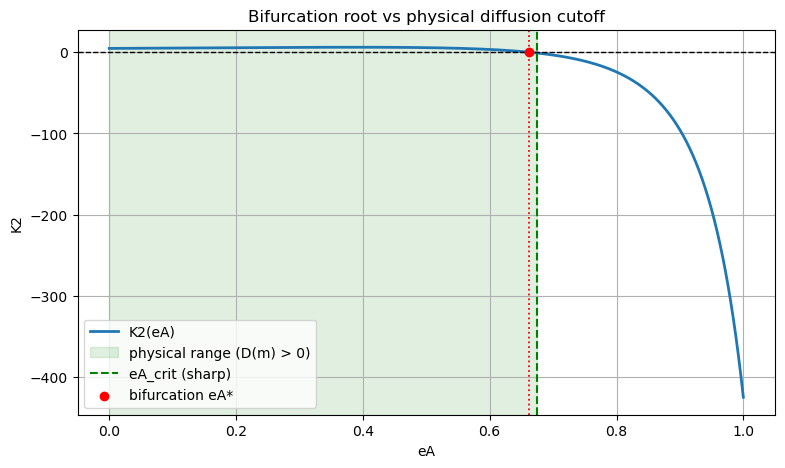

In [18]:
eA_plot_max = max(params['eA_max'], analysis['eA_crit_sharp'] * 1.05)
eA_grid = np.linspace(params['eA_min'], eA_plot_max, 1201)
eA_vals, K2_vals = K2_of_eA(F, SO, eA_grid, m_inf=params['m_inf'])

plt.figure()
plt.plot(eA_vals, K2_vals, linewidth=2, label='K2(eA)')
plt.axhline(0.0, linestyle='--', linewidth=1, color='black')

phys_right = analysis['eA_crit_strict'] if params['strict_physical'] else analysis['eA_crit_sharp']
plt.axvspan(params['eA_min'], phys_right, alpha=0.12, color='green', label='physical range (D(m) > 0)')
plt.axvline(analysis['eA_crit_sharp'], linestyle='--', color='green', linewidth=1.5, label='eA_crit (sharp)')

if analysis['root_eA_pos_to_neg'] is not None:
    root = analysis['root_eA_pos_to_neg']
    root_k2 = float(np.interp(root, eA_vals, K2_vals))
    plt.scatter([root], [root_k2], color='red', zorder=5, label='bifurcation eA*')
    plt.axvline(root, linestyle=':', color='red', linewidth=1.3)

plt.xlabel('eA')
plt.ylabel('K2')
plt.title('Bifurcation root vs physical diffusion cutoff')
plt.legend()
plt.show()


In [19]:
tests = [
    0.99 * analysis['eA_crit_sharp'],
    1.00 * analysis['eA_crit_sharp'],
    1.01 * analysis['eA_crit_sharp'],
]

for e in tests:
    minD, m_at_min = min_D_on_domain(e, params['m_inf'])
    print(
        f"eA={e:.8f}  min D~{minD:.6e} at m~{m_at_min:.6f}  "
        f"physical(strict)? {is_eA_physical_vdw(e, m_inf=params['m_inf'], strict=True, eps=params['eps_physical'])}"
    )

if analysis['root_eA_pos_to_neg'] is not None:
    e_star = analysis['root_eA_pos_to_neg']
    minD_star, m_star = min_D_on_domain(e_star, params['m_inf'])
    print()
    print(f"at bifurcation eA*= {e_star:.10f}: min D~{minD_star:.6e} at m~{m_star:.6f}")


eA=0.66825000  min D~2.242467e-02 at m~3.310866  physical(strict)? True
eA=0.67500000  min D~6.750858e-10 at m~3.333267  physical(strict)? False
eA=0.68175000  min D~-2.257467e-02 at m~3.355467  physical(strict)? False

at bifurcation eA*= 0.6626674180: min D~4.085619e-02 at m~3.292266


## Parameter Search: Physical Bifurcation Region

This section scans a grid of `(P, Z, gamma)` and keeps only points where:
- a `K2` sign change `(+ -> -)` is detected in `eA`, and
- the corresponding bifurcation root `eA*` is inside the physical range where `D(m) > 0`.


In [9]:
from itertools import product


def sweep_param_grid_physical_bifurcation(
    P_vals,
    Z_vals,
    gamma_vals,
    *,
    root_index=0,
    m_inf=10.0,
    eA_min=0.0,
    eA_max=1.0,
    n_scan=401,
    tol=1e-10,
    max_iter=60,
    second_order_N_init=500,
    strict_physical=True,
    eps_physical=1e-10,
    verbose=True,
):
    eA_crit_sharp = critical_eA_positive_vdw(m_inf=m_inf, strict=False, eps=eps_physical)
    eA_crit_strict = critical_eA_positive_vdw(m_inf=m_inf, strict=True, eps=eps_physical)
    eA_phys_right = eA_crit_strict if strict_physical else eA_crit_sharp

    records = []
    hits = []

    total = len(P_vals) * len(Z_vals) * len(gamma_vals)
    done = 0

    for P, Z, gamma in product(P_vals, Z_vals, gamma_vals):
        done += 1
        rec = {
            'P': float(P),
            'Z': float(Z),
            'gamma': float(gamma),
            'ok': False,
            'error': None,
            'changed_to_negative': False,
            'root_eA': None,
            'root_in_physical_range': None,
            'eA_phys_right': float(eA_phys_right),
        }

        try:
            if verbose:
                print(f"[{done}/{total}] P={P:.6g}, Z={Z:.6g}, gamma={gamma:.6g}")

            F_loc = build_first_order(P=P, Z=Z, gamma=gamma, root_index=root_index)
            SO_loc = compute_second_order(F_loc, N_init=second_order_N_init)

            bif = find_bifurcation_change_to_negative(
                F_loc,
                SO_loc,
                eA_min,
                eA_max,
                m_inf=m_inf,
                n_scan=n_scan,
                tol=tol,
                max_iter=max_iter,
            )

            root = first_pos_to_neg_root(bif['crossings'])
            in_phys = None if root is None else bool(root < eA_phys_right if strict_physical else root <= eA_phys_right)

            rec['ok'] = True
            rec['changed_to_negative'] = bool(root is not None)
            rec['root_eA'] = None if root is None else float(root)
            rec['root_in_physical_range'] = in_phys

            if root is not None and in_phys:
                rec['margin_to_phys_limit'] = float(eA_phys_right - root)
                hits.append(rec.copy())

        except Exception as exc:
            rec['error'] = f"{type(exc).__name__}: {exc}"

        records.append(rec)

    return {
        'records': records,
        'hits': hits,
        'eA_crit_sharp': float(eA_crit_sharp),
        'eA_crit_strict': float(eA_crit_strict),
        'eA_phys_right': float(eA_phys_right),
        'strict_physical': bool(strict_physical),
    }


def summarize_hit_ranges(hits):
    if len(hits) == 0:
        print('No physical +->- bifurcation hits found in this grid.')
        return

    P = np.array([h['P'] for h in hits], dtype=float)
    Z = np.array([h['Z'] for h in hits], dtype=float)
    G = np.array([h['gamma'] for h in hits], dtype=float)
    R = np.array([h['root_eA'] for h in hits], dtype=float)

    print(f"hits: {len(hits)}")
    print(f"P range among hits: [{P.min():.6g}, {P.max():.6g}]")
    print(f"Z range among hits: [{Z.min():.6g}, {Z.max():.6g}]")
    print(f"gamma range among hits: [{G.min():.6g}, {G.max():.6g}]")
    print(f"eA* range among hits: [{R.min():.6g}, {R.max():.6g}]")


def print_first_hits(hits, n=20):
    if len(hits) == 0:
        return
    print('First hits (P, Z, gamma, eA*, margin_to_phys_limit):')
    for h in hits[:int(n)]:
        print(
            f"  P={h['P']:.6g}, Z={h['Z']:.6g}, gamma={h['gamma']:.6g}, "
            f"eA*={h['root_eA']:.8f}, margin={h.get('margin_to_phys_limit', np.nan):.3e}"
        )


In [10]:
sweep_cfg = {
    # Start coarse; then narrow around hit ranges and increase resolution.
    'P_vals': np.linspace(0.012, 0.020, 5),
    'Z_vals': np.linspace(0.12, 0.20, 5),
    'gamma_vals': np.linspace(0.001, 0.006, 4),
    'root_index': 0,
    'm_inf': params['m_inf'],
    'eA_min': params['eA_min'],
    'eA_max': params['eA_max'],
    'n_scan': 301,
    'tol': 1e-10,
    'max_iter': 70,
    'second_order_N_init': 350,
    'strict_physical': True,
    'eps_physical': params['eps_physical'],
    'verbose': True,
}
sweep_cfg


{'P_vals': array([0.012, 0.014, 0.016, 0.018, 0.02 ]),
 'Z_vals': array([0.12, 0.14, 0.16, 0.18, 0.2 ]),
 'gamma_vals': array([0.001     , 0.00266667, 0.00433333, 0.006     ]),
 'root_index': 0,
 'm_inf': 10.0,
 'eA_min': 0.0,
 'eA_max': 1.0,
 'n_scan': 301,
 'tol': 1e-10,
 'max_iter': 70,
 'second_order_N_init': 350,
 'strict_physical': True,
 'eps_physical': 1e-10,
 'verbose': True}

In [11]:
sweep_res = sweep_param_grid_physical_bifurcation(**sweep_cfg)

records = sweep_res['records']
hits = sweep_res['hits']

print('--- Sweep summary ---')
print('total points:', len(records))
print('successful points:', sum(1 for r in records if r['ok']))
print('failed points:', sum(1 for r in records if not r['ok']))
print('physical +->- hits:', len(hits))
print('physical eA upper bound used:', sweep_res['eA_phys_right'])

summarize_hit_ranges(hits)
print_first_hits(hits, n=25)


[1/100] P=0.012, Z=0.12, gamma=0.001
[2/100] P=0.012, Z=0.12, gamma=0.00266667
[3/100] P=0.012, Z=0.12, gamma=0.00433333
[4/100] P=0.012, Z=0.12, gamma=0.006
[5/100] P=0.012, Z=0.14, gamma=0.001
[6/100] P=0.012, Z=0.14, gamma=0.00266667
[7/100] P=0.012, Z=0.14, gamma=0.00433333
[8/100] P=0.012, Z=0.14, gamma=0.006
[9/100] P=0.012, Z=0.16, gamma=0.001
[10/100] P=0.012, Z=0.16, gamma=0.00266667
[11/100] P=0.012, Z=0.16, gamma=0.00433333
[12/100] P=0.012, Z=0.16, gamma=0.006
[13/100] P=0.012, Z=0.18, gamma=0.001
[14/100] P=0.012, Z=0.18, gamma=0.00266667
[15/100] P=0.012, Z=0.18, gamma=0.00433333
[16/100] P=0.012, Z=0.18, gamma=0.006
[17/100] P=0.012, Z=0.2, gamma=0.001
[18/100] P=0.012, Z=0.2, gamma=0.00266667
[19/100] P=0.012, Z=0.2, gamma=0.00433333
[20/100] P=0.012, Z=0.2, gamma=0.006
[21/100] P=0.014, Z=0.12, gamma=0.001
[22/100] P=0.014, Z=0.12, gamma=0.00266667
[23/100] P=0.014, Z=0.12, gamma=0.00433333
[24/100] P=0.014, Z=0.12, gamma=0.006
[25/100] P=0.014, Z=0.14, gamma=0.001
[26

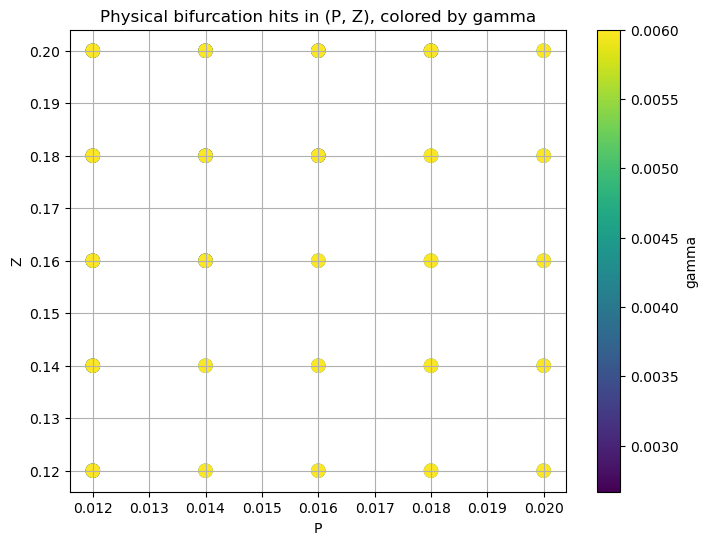

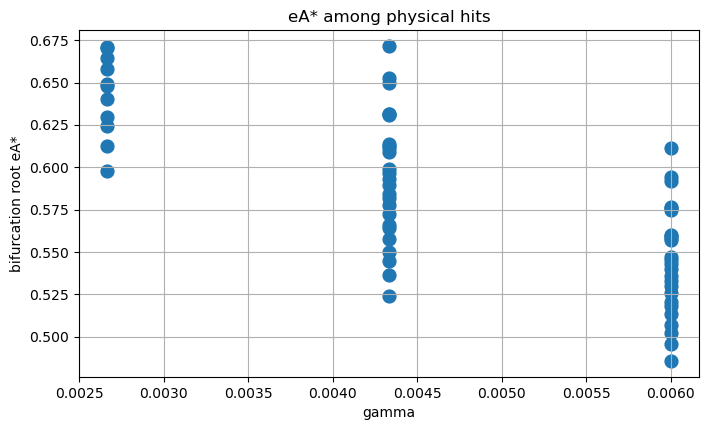

In [12]:
if len(sweep_res['hits']) > 0:
    P = np.array([h['P'] for h in sweep_res['hits']], dtype=float)
    Z = np.array([h['Z'] for h in sweep_res['hits']], dtype=float)
    G = np.array([h['gamma'] for h in sweep_res['hits']], dtype=float)
    R = np.array([h['root_eA'] for h in sweep_res['hits']], dtype=float)

    plt.figure(figsize=(8, 6))
    sc = plt.scatter(P, Z, c=G, s=90, cmap='viridis')
    cbar = plt.colorbar(sc)
    cbar.set_label('gamma')
    plt.xlabel('P')
    plt.ylabel('Z')
    plt.title('Physical bifurcation hits in (P, Z), colored by gamma')
    plt.show()

    plt.figure(figsize=(8, 4.5))
    plt.scatter(G, R, s=85)
    plt.xlabel('gamma')
    plt.ylabel('bifurcation root eA*')
    plt.title('eA* among physical hits')
    plt.show()
else:
    print('No hits to plot.')
